# 21 — Self-supervised pretraining: a *small foundation model for human input motion* (Phase 8)

The architecture comparison (notebook 16) and the public-corpus scale study (notebook 19) both
landed on the same conclusion: **the binding constraint on this project is data, not model
capacity.** Phase 8 attacks that directly. We pretrain the sequence encoder *self-supervised* on a
large unlabelled human-mouse corpus, then ask the only question that matters:

> Does pretraining let the downstream chunk-level cheat detector reach the same performance with
> **fewer** fine-tuning sessions?

That is the **data-efficiency curve** — chunk-AUC vs the number of fine-tuning units, *pretrained-init
vs from-scratch-init* — and we run it on **both** real-cheat datasets: **CS2CD** (10 players, real
third-party cheats) and **GTA** (N=18, synthetic cheats).

**Honest framing up front (the project rule):** a null result — pretraining doesn't transfer because
the captcha→game domain gap dominates — is a *publishable finding*, not a failure. We measure the gap
first so the verdict is interpretable either way.

This notebook **loads** the artifacts produced by the GPU scripts (so it runs CPU-fast); the heavy
training lives in:

- `python -m scripts.pretrain_encoder`   — masked-denoising pretraining on CaptchaSolve30k
- `python -m scripts.domain_gap_report`  — captcha→CS2CD / captcha→GTA KS+PSI
- `python -m scripts.data_efficiency --domain {cs2cd,gta}` — the curves

Code lives in `pipeline/pretraining/`; the write-up is `docs/PRETRAINING.md`.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

ROOT = Path().resolve().parent if Path().resolve().name == "notebooks" else Path().resolve()
sys.path.insert(0, str(ROOT))   # make the repo importable when run from notebooks/
REPORTS = ROOT / "reports"
FIGS = REPORTS / "figures"
print("repo root:", ROOT)

repo root: /home/hydra/workspace/behaviorDNA


## 1 · One shared input schema — the precondition for transfer

Transfer is only *mechanically* valid if the encoder sees the same input dimension **and the same
channel semantics** at pretrain, fine-tune, and eval time. So all three corpora map onto the existing
8-D event tensor from `pipeline/sequences/preprocessing.py`:

```
[dt, dx, dy, is_mouse_move, is_mouse_click_press, is_mouse_scroll, is_key_press, is_key_release]
```

- **GTA** is already native (event stream).
- **CaptchaSolve30k** and **CS2CD** are *sampled* streams — one mouse sample per physics/engine tick
  — so we adopt one convention: every tick is a movement sample (`is_mouse_move=1` with `dx/dy`
  deltas), the click channel fires on the button's **rising edge**, `dt = log1p(ms_per_tick)` (near
  constant), scroll/keyboard = 0.

That *sampled-vs-event* difference is itself part of the domain gap, and we'll see it surface loudly
in the `dt` channel below. Let's load a few captcha sessions and look at one trajectory.

loaded 20 captcha mouse sessions; e.g. shape (1978, 8)


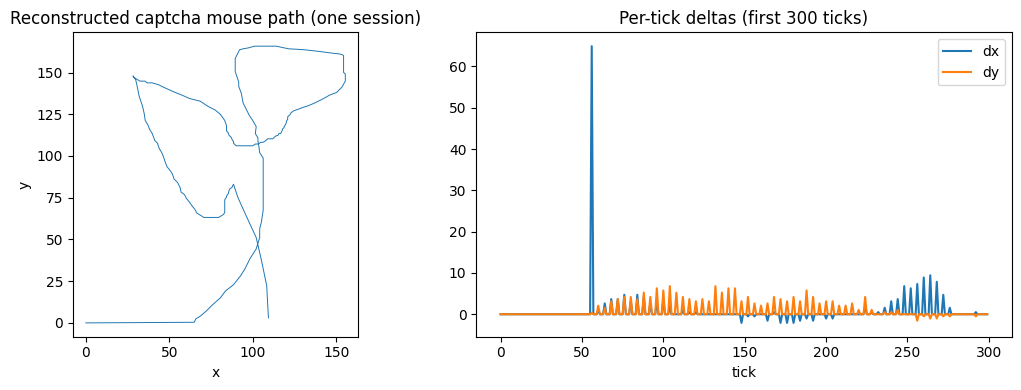

In [2]:
from pipeline.pretraining.corpora import captcha_to_tensors
from pipeline.sequences.preprocessing import COL_DX, COL_DY

tensors = captcha_to_tensors(max_sessions=20, seed=42)   # ~3s, CPU
print(f"loaded {len(tensors)} captcha mouse sessions; e.g. shape {tensors[0].shape}")

t = tensors[0]
path = np.cumsum(t[:, [COL_DX, COL_DY]], axis=0)   # integrate deltas back to a trajectory
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(path[:, 0], path[:, 1], lw=0.7)
ax[0].set_title("Reconstructed captcha mouse path (one session)")
ax[0].set_xlabel("x")
ax[0].set_ylabel("y")
ax[0].set_aspect("equal", "box")
ax[1].plot(t[:300, COL_DX], label="dx")
ax[1].plot(t[:300, COL_DY], label="dy")
ax[1].set_title("Per-tick deltas (first 300 ticks)")
ax[1].legend()
ax[1].set_xlabel("tick")
fig.tight_layout()
plt.show()

## 2 · The pretext task — masked-step denoising

We zero out a random fraction of timesteps in the input and train the autoencoder to reconstruct the
**clean** chunk. To fill in masked steps the bottleneck has to learn the *structure* of how a human
hand moves a mouse — exactly the prior we hope to transfer into the legit-manifold anomaly detector.
This reuses the existing `LSTMAutoencoder` unchanged; only the training pair changes
(`MSE(model(masked), clean)`).

masked 10/64 timesteps: [ 1  2  4 11 15 18 29 35 46 52]


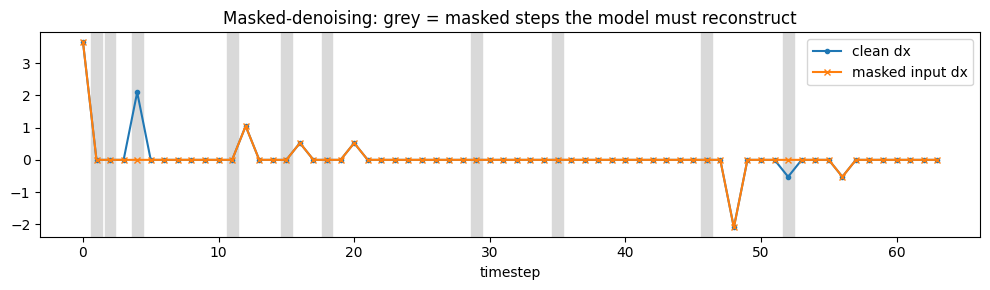

In [3]:
from pipeline.pretraining.masking import mask_chunk

chunk = t[100:164].copy()                     # one 64-step window
masked = mask_chunk(chunk, frac=0.15, rng=np.random.default_rng(0))
zeroed = np.where(masked.sum(axis=1) == 0)[0]
print(f"masked {len(zeroed)}/64 timesteps:", zeroed)

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(chunk[:, COL_DX], "-o", ms=3, label="clean dx")
ax.plot(masked[:, COL_DX], "-x", ms=4, label="masked input dx")
for z in zeroed:
    ax.axvspan(z - 0.4, z + 0.4, color="0.85", zorder=0)
ax.set_title("Masked-denoising: grey = masked steps the model must reconstruct")
ax.set_xlabel("timestep")
ax.legend()
fig.tight_layout()
plt.show()

## 3 · The captcha → game domain gap (measured *before* claiming transfer)

We encode all three corpora to 8-D and run the project's existing KS + PSI drift tooling
(`pipeline/monitoring/drift.py`) on the per-channel distributions, with the pretraining corpus
(captcha) as the reference. Big PSI ⇒ that channel's distribution differs ⇒ less likely to transfer.


=== captcha_vs_cs2cd (reference = CaptchaSolve30k) ===
             feature  ks_stat       psi psi_severity
                  dt 0.999200 11.759343  significant
                  dx 0.052454  0.080766         none
                  dy 0.057565  0.060465         none
is_mouse_click_press 0.001040  0.000000         none
       is_mouse_move 0.000000       NaN      unknown

=== captcha_vs_gta (reference = CaptchaSolve30k) ===
             feature  ks_stat      psi psi_severity
                  dt 0.878190 9.804852  significant
                  dx 0.214990 0.370991  significant
                  dy 0.069515 0.044666         none
is_mouse_click_press 0.000300 0.000000         none
       is_mouse_move 0.053145      NaN      unknown


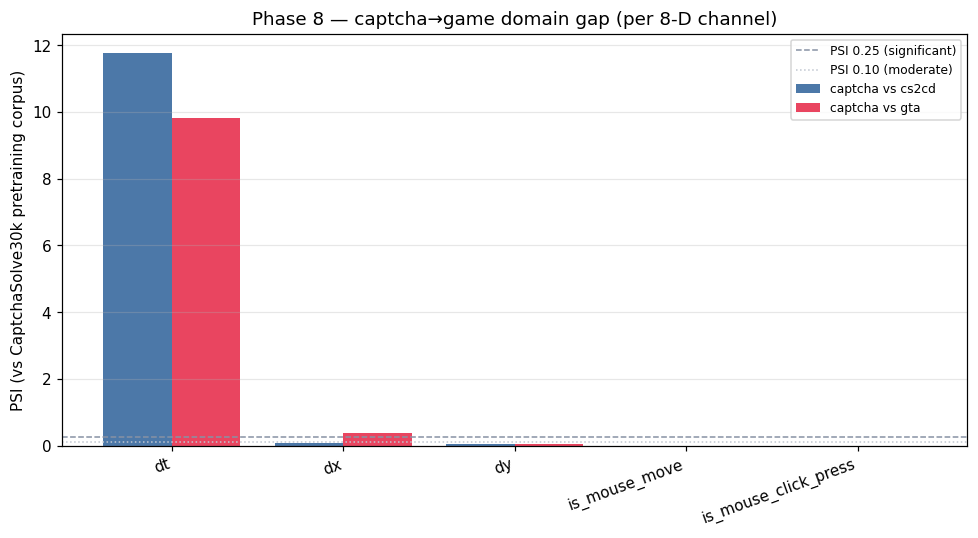

In [4]:
dg = json.load(open(REPORTS / "pretraining_domain_gap.json"))
for comp, rows in dg.items():
    print(f"\n=== {comp} (reference = CaptchaSolve30k) ===")
    df = pd.DataFrame(rows)[["feature", "ks_stat", "psi", "psi_severity"]]
    print(df.to_string(index=False))

display(Image(filename=str(FIGS / "phase8_domain_gap.png")))

**Read it honestly:**

- The **`dt` channel is wildly shifted** (PSI ≈ 10–12, KS ≈ 0.88–0.999). That's the sampled-vs-event
  distinction made concrete: captcha is a fixed ~4.2 ms tick, CS2 a fixed ~15.6 ms tick, and GTA is
  event-driven with real idle gaps. The *temporal* encoding barely overlaps.
- The **movement geometry transfers far better to CS2 than to GTA**: captcha→CS2 `dx`/`dy` PSI < 0.1
  (no meaningful shift), but captcha→GTA `dx` PSI ≈ 0.37 (significant). GTA mouse deltas live in a
  different regime (sens/DPI-normalised game aim) than captcha drag-to-target motion.

So before we even fine-tune, the gap predicts **weak transfer** — strongest where it'd matter least
(`dt`).

## 4 · The headline — data-efficiency curves

For a budget axis (number of legit fine-tuning units) × {pretrained-init, scratch-init} × 5 seeds, we
fine-tune the AE and score a **fixed** legit-vs-cheat chunk-AUC eval set. If pretraining helps, the
blue (pretrained) line sits **above** the red (scratch) line, especially at low budget.

=== CS2CD ===
 budget    pretrained       scratch Δ (pre−scratch)
      1 0.703 ± 0.005 0.702 ± 0.005          +0.000
      2 0.702 ± 0.005 0.702 ± 0.005          +0.000
      5 0.698 ± 0.002 0.698 ± 0.002          +0.000
     10 0.699 ± 0.000 0.698 ± 0.000          +0.000


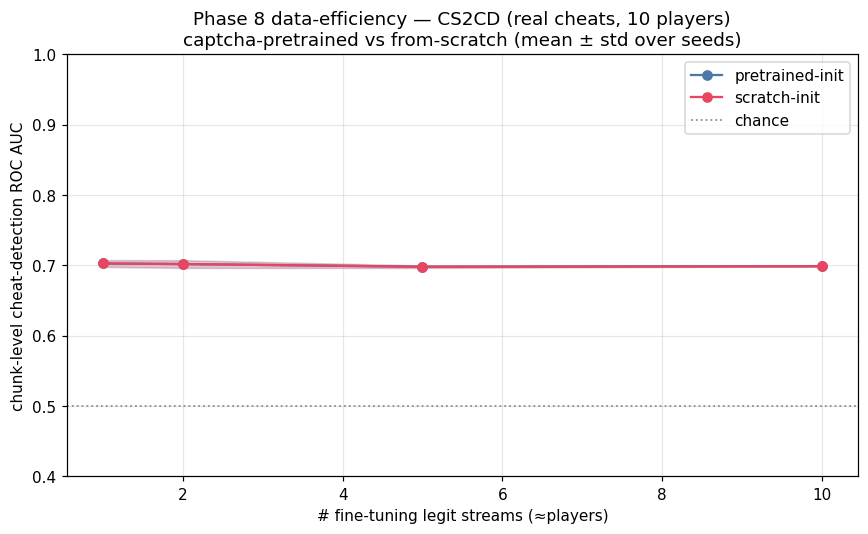

=== GTA ===
 budget    pretrained       scratch Δ (pre−scratch)
      2 0.538 ± 0.023 0.539 ± 0.022          -0.001
      5 0.549 ± 0.023 0.553 ± 0.022          -0.004
     10 0.557 ± 0.006 0.562 ± 0.005          -0.005
     15 0.556 ± 0.004 0.561 ± 0.003          -0.005


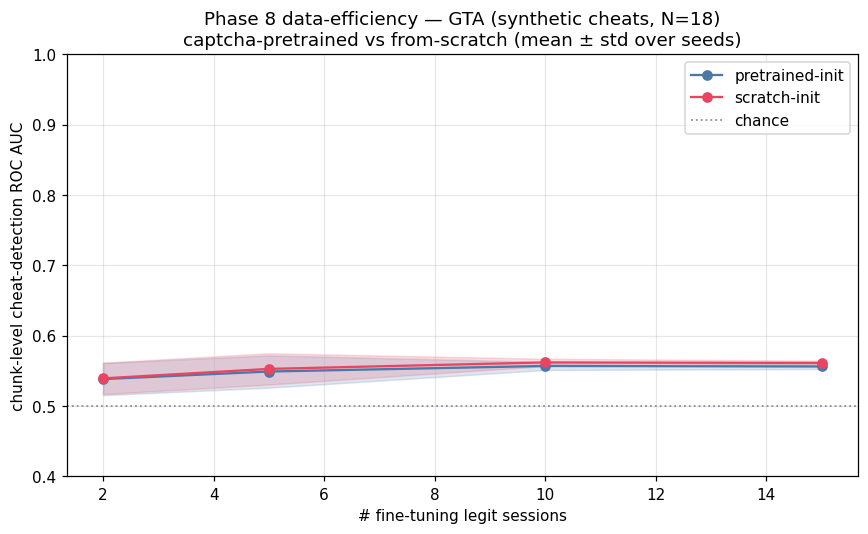

In [5]:
def show_curve(domain):
    d = json.load(open(REPORTS / f"data_efficiency_{domain}.json"))
    pre = {p["budget"]: p for p in d["summary"]["pretrained"]}
    scr = {p["budget"]: p for p in d["summary"]["scratch"]}
    rows = []
    for b in sorted(pre):
        rows.append({"budget": b,
                     "pretrained": f"{pre[b]['mean']:.3f} ± {pre[b]['std']:.3f}",
                     "scratch": f"{scr[b]['mean']:.3f} ± {scr[b]['std']:.3f}",
                     "Δ (pre−scratch)": f"{pre[b]['mean'] - scr[b]['mean']:+.3f}"})
    print(f"=== {domain.upper()} ===")
    print(pd.DataFrame(rows).to_string(index=False))
    display(Image(filename=str(FIGS / f"phase8_data_efficiency_{domain}.png")))

show_curve("cs2cd")
show_curve("gta")

## 5 · Verdict — a rigorous null

| Dataset | Pretrained vs scratch | Reading |
|---|---|---|
| **CS2CD** (real cheats) | Δ ≈ **0.000** at every budget; AUC flat ≈ 0.70 | No transfer benefit — *and* the task is near-separable at random init (the cheat snaps have larger deltas → higher reconstruction error even untrained), so CS2CD is a weak discriminator of the transfer question. |
| **GTA** (synthetic) | Δ = **−0.001 … −0.005** (within ±std) | No benefit; if anything pretrained is a hair *worse*. Fine-tuning itself helps (AUC climbs 0.54→0.56 with budget); pretraining specifically does not. |

**At this scale, with masked-denoising on the 8-D event tensors, captcha-pretraining does not buy
data-efficiency on either downstream cheat-detection task.** And the domain-gap report tells us *why*:
the transferable prior we learned (human drag-to-target motion, fixed-tick) is exactly mismatched to
the game-aim regime on the channel that carries the most structure (`dt`, and `dx` for GTA).

This is the outcome the roadmap explicitly flagged as valid: *"pretraining-doesn't-help = domain gap
dominates, also a real result."* It's also a useful negative result for the field — a generic
human-mouse corpus is **not** a drop-in foundation for game-input biometrics.

### What would change the verdict (the honest next steps)
1. **Match the temporal encoding** — resample game streams to a fixed tick (or drop `dt`) so the
   pretraining prior isn't fighting a 10-PSI mismatch on its most-structured channel.
2. **A combat-dense, in-domain pretraining corpus** (game mouse, not captcha) — the geometry gap to
   GTA (`dx` PSI 0.37) says out-of-domain motion is the problem, not the method.
3. **A contrastive objective** (the Phase 8 stretch goal) instead of reconstruction, which is
   dominated by input magnitude (see the CS2CD init-separability caveat).

See `docs/PRETRAINING.md` for the full write-up and reproduction steps.